# PhillyStat360 — 05: Output Analysis (Python / Colab port)

Port of `code/05_output_analysis_v3.Rmd`. Stakeholder-facing analysis of the
final ensemble predictions:

- §2 — Distribution by OPA property category (tables + density plots)
- §3 — Spatial summary by ZIP code (bar chart + choropleth)
- §4 — Capacity-based threshold table — answers "if we can inspect N parcels,
   what threshold should we use?"
- §5 — GeoJSON export for dashboards (optional, heavy)

Uses the **ensemble** probability column from `data_py/all_predictions_rf.csv`
as the primary score throughout.


## 0. Setup

In [1]:
# Mount Google Drive (run once per Colab session)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os
from pathlib import Path

ROOT       = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
RAW_PATH   = ROOT / 'rawdata'         # original CSVs / geojsons
DATA_PATH  = ROOT / 'data'            # R-side outputs (features_residential.csv, ovs_residential.csv)
PY_PATH    = ROOT / 'data_py'         # 04a Python outputs (predictions, models, calibrators)
OUT_PATH   = ROOT / 'data_py'         # we WRITE here too
GRAPH_PATH = ROOT / 'graphs' / 'python'

OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)

assert (PY_PATH / 'all_predictions_rf.csv').exists(), \
    f'04a outputs not found at {PY_PATH}. Run 04a_tidymodeling.ipynb first.'
print('All paths OK. PY_PATH =', PY_PATH)


All paths OK. PY_PATH = /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py


In [3]:
%pip install -q geopandas folium pygris


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.8 MB/s eta 0:00:00


In [4]:
import json
import joblib
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, brier_score_loss,
                             confusion_matrix, classification_report)

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42

# Optional spatial libraries
try:
    import geopandas as gpd
    HAS_GPD = True
except ImportError:
    HAS_GPD = False
    print('geopandas missing — spatial steps will be skipped')

try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print('folium missing — interactive map will be skipped')


## 1. Load predictions & metadata

In [5]:
preds = pd.read_csv(PY_PATH / 'all_predictions_rf.csv', low_memory=False)
preds['parcel_number'] = preds['parcel_number'].astype(str)
print(f"Predictions: {len(preds):,} rows")

features_df = pd.read_csv(DATA_PATH / 'features_residential.csv', low_memory=False)
features_df['parcel_number'] = features_df['parcel_number'].astype(str)

ovs_meta = pd.read_csv(DATA_PATH / 'ovs_residential.csv', low_memory=False)
ovs_meta['parcel_number'] = ovs_meta['parcel_number'].astype(str)
ovs_meta = ovs_meta[['parcel_number', 'category_code',
                     'category_code_description', 'zip_code',
                     'census_tract', 'zoning']].drop_duplicates(subset='parcel_number')

# Pull geographic_ward and property address (location) from raw OPA so the
# GeoJSON export carries them
opa_extra = pd.read_csv(RAW_PATH / 'opa_properties_public.csv',
                        usecols=['parcel_number', 'geographic_ward', 'location'],
                        low_memory=False)
opa_extra['parcel_number'] = opa_extra['parcel_number'].astype(str)
opa_extra = opa_extra.rename(columns={'location': 'address'})
opa_extra = opa_extra.drop_duplicates(subset='parcel_number')
ovs_meta = ovs_meta.merge(opa_extra, on='parcel_number', how='left')

prob_col     = 'ensemble_prob'     if 'ensemble_prob'     in preds.columns else 'rf_prob'
prob_raw_col = 'ensemble_prob_raw' if 'ensemble_prob_raw' in preds.columns else 'rf_prob'
print(f"Primary probability column: {prob_col}  (raw: {prob_raw_col})")

analysis = (
    preds
    .merge(features_df[['parcel_number', 'exterior_condition', 'building_age',
                        'log_livable_area']],
           on='parcel_number', how='left')
    .merge(ovs_meta, on='parcel_number', how='left')
)
print(f"analysis_df: {len(analysis):,} parcels")
print(f"  OVS=1 (observed): {int((analysis['ovs'] == 1).sum()):,}")
print(f"  category_code_description present for "
      f"{analysis['category_code_description'].notna().sum():,} parcels")


Predictions: 520,196 rows
Primary probability column: ensemble_prob  (raw: ensemble_prob_raw)
analysis_df: 520,196 parcels
  OVS=1 (observed): 5,934
  category_code_description present for 520,196 parcels


## 2. Distribution by OPA category

### 2a. Per-category table

In [6]:
type_summary = (
    analysis.dropna(subset=['category_code_description'])
    .groupby('category_code_description')
    .agg(n_parcels=('parcel_number', 'size'),
         n_observed_vac=('ovs', lambda s: int((s == 1).sum())),
         obs_rate=('ovs', lambda s: float((s == 1).mean())),
         mean_pred_prob=(prob_col, 'mean'),
         median_pred_prob=(prob_col, 'median'))
    .reset_index()
    .sort_values('mean_pred_prob', ascending=False)
)
type_summary.round(4)


,category_code_description,n_parcels,n_observed_vac,obs_rate,mean_pred_prob,median_pred_prob
1,MIXED USE,14021,344,0.0245,0.0273,0.0043
2,MULTI FAMILY,40892,603,0.0147,0.0168,0.0030
0,APARTMENTS > 4 UNITS,3621,31,0.0086,0.0123,0.0030
3,SINGLE FAMILY,461662,4956,0.0107,0.0120,0.0012


### 2b. Density plot by major categories

Plotting 520,196 of 520,196 parcels (raw prob > 0)


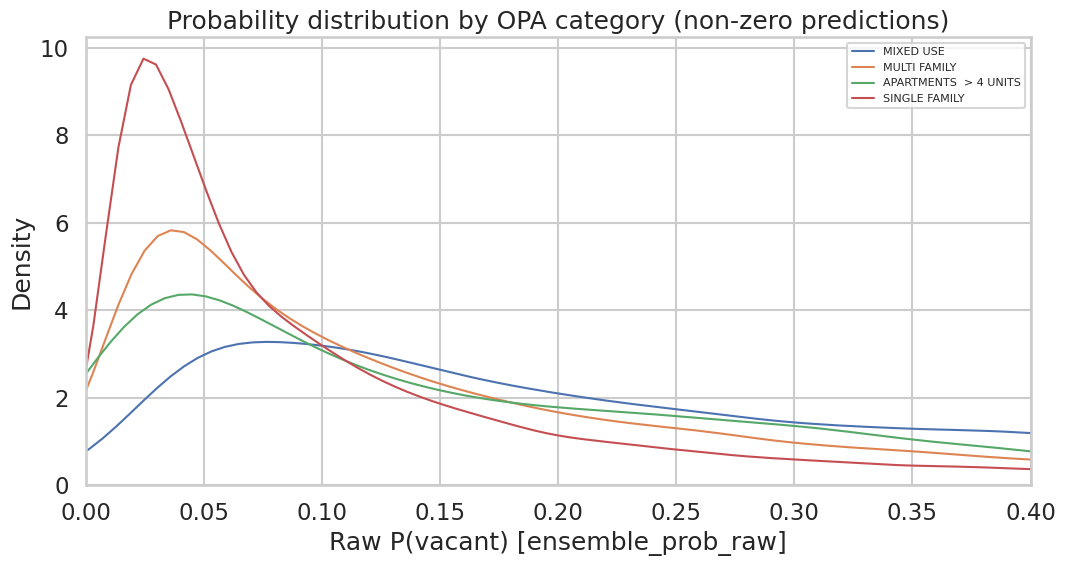

In [7]:
major_cats = type_summary[type_summary['n_parcels'] >= 500]['category_code_description'].tolist()
plot_df = analysis[analysis['category_code_description'].isin(major_cats)]

# Use raw probabilities (better spread for visualization than calibrated)
nonzero = plot_df[plot_df[prob_raw_col] > 0]
print(f"Plotting {len(nonzero):,} of {len(plot_df):,} parcels (raw prob > 0)")

fig, ax = plt.subplots(figsize=(11, 6))
for cat in major_cats:
    sub = nonzero[nonzero['category_code_description'] == cat]
    if len(sub) >= 20:
        sns.kdeplot(sub[prob_raw_col], ax=ax, label=cat, linewidth=1.5)
ax.set_xlim(0, 0.4)
ax.set_xlabel(f'Raw P(vacant) [{prob_raw_col}]')
ax.set_ylabel('Density')
ax.set_title('Probability distribution by OPA category (non-zero predictions)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'prob_distribution_by_category.png', dpi=200, bbox_inches='tight')
plt.show()


### 2c. Mean P(vacant) and tier breakdown by category

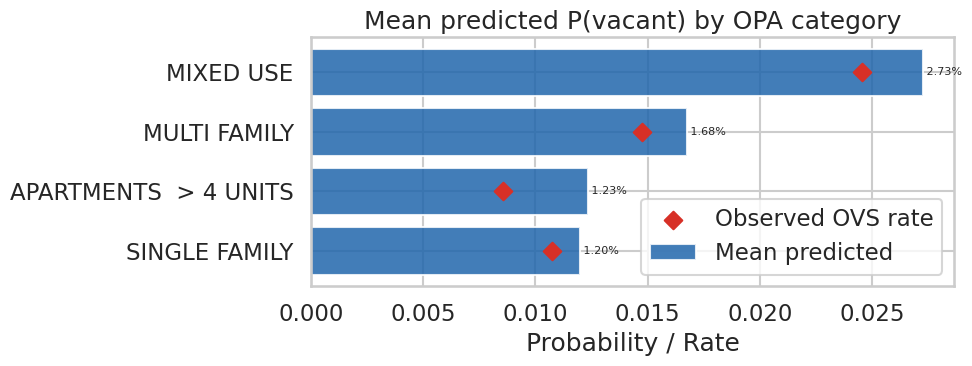

In [8]:
mean_prob_cat = (
    analysis[analysis['category_code_description'].isin(major_cats)]
    .groupby('category_code_description')
    .agg(mean_prob=(prob_col, 'mean'),
         obs_rate=('ovs', lambda s: float((s == 1).mean())))
    .reset_index()
    .sort_values('mean_prob')
)

fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(mean_prob_cat))))
y = np.arange(len(mean_prob_cat))
ax.barh(y, mean_prob_cat['mean_prob'], color='#2166ac', alpha=0.85, label='Mean predicted')
ax.scatter(mean_prob_cat['obs_rate'], y, color='#d73027', s=80, zorder=5,
           marker='D', label='Observed OVS rate')
for i, v in enumerate(mean_prob_cat['mean_prob']):
    ax.text(v, i, f' {v:.2%}', va='center', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(mean_prob_cat['category_code_description'])
ax.set_xlabel('Probability / Rate')
ax.set_title('Mean predicted P(vacant) by OPA category')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'mean_prob_by_category.png', dpi=200, bbox_inches='tight')
plt.show()


### 2d. Category calibration plot

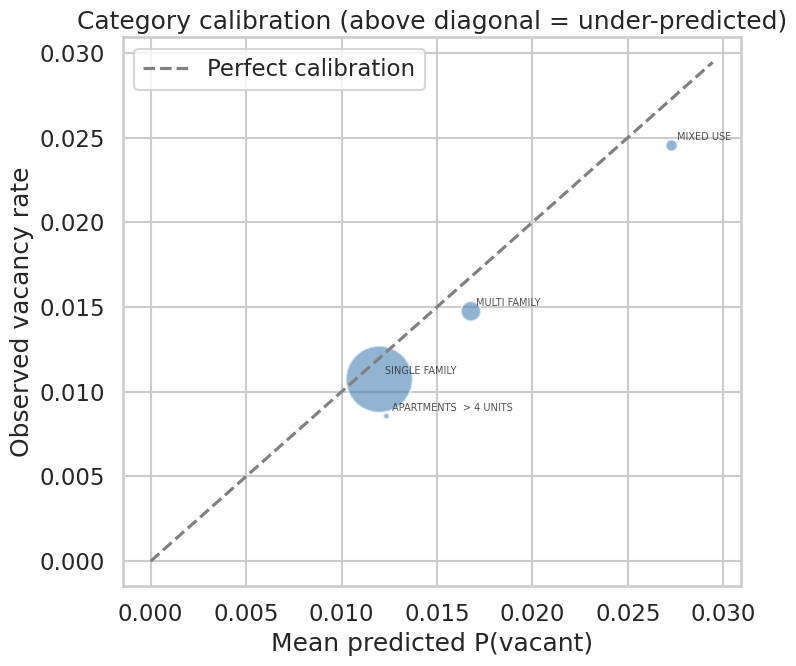

In [9]:
calib = type_summary[type_summary['n_parcels'] >= 200].copy()

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, calib['obs_rate'].max() * 1.2], [0, calib['obs_rate'].max() * 1.2],
        '--', color='gray', label='Perfect calibration')
ax.scatter(calib['mean_pred_prob'], calib['obs_rate'],
           s=calib['n_parcels'] / 200, alpha=0.6, color='steelblue',
           edgecolors='white')
for _, row in calib.iterrows():
    ax.annotate(row['category_code_description'][:25],
                (row['mean_pred_prob'], row['obs_rate']),
                fontsize=7, alpha=0.8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Mean predicted P(vacant)')
ax.set_ylabel('Observed vacancy rate')
ax.set_title('Category calibration (above diagonal = under-predicted)')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'category_calibration.png', dpi=200, bbox_inches='tight')
plt.show()


## 3. Spatial summary by ZIP

In [10]:
zip_summary = (
    analysis.dropna(subset=['zip_code'])
    .groupby('zip_code')
    .agg(n_parcels=('parcel_number', 'size'),
         n_obs_vacant=('ovs', lambda s: int((s == 1).sum())),
         obs_rate=('ovs', lambda s: float((s == 1).mean())),
         mean_pred_prob=(prob_col, 'mean'))
    .reset_index()
    .sort_values('mean_pred_prob', ascending=False)
)
zip_summary.head(20).round(4)


,zip_code,n_parcels,n_obs_vacant,obs_rate,mean_pred_prob
24,19132.0,15581,592,0.0380,0.0361
31,19139.0,14713,407,0.0277,0.0326
32,19140.0,18805,484,0.0257,0.0307
13,19121.0,11867,339,0.0286,0.0295
26,19134.0,21910,567,0.0259,0.0294
2,19104.0,8783,219,0.0249,0.0269
35,19143.0,23461,515,0.0220,0.0263
36,19144.0,11504,231,0.0201,0.0236
34,19142.0,10243,215,0.0210,0.0227
23,19131.0,13518,265,0.0196,0.0215


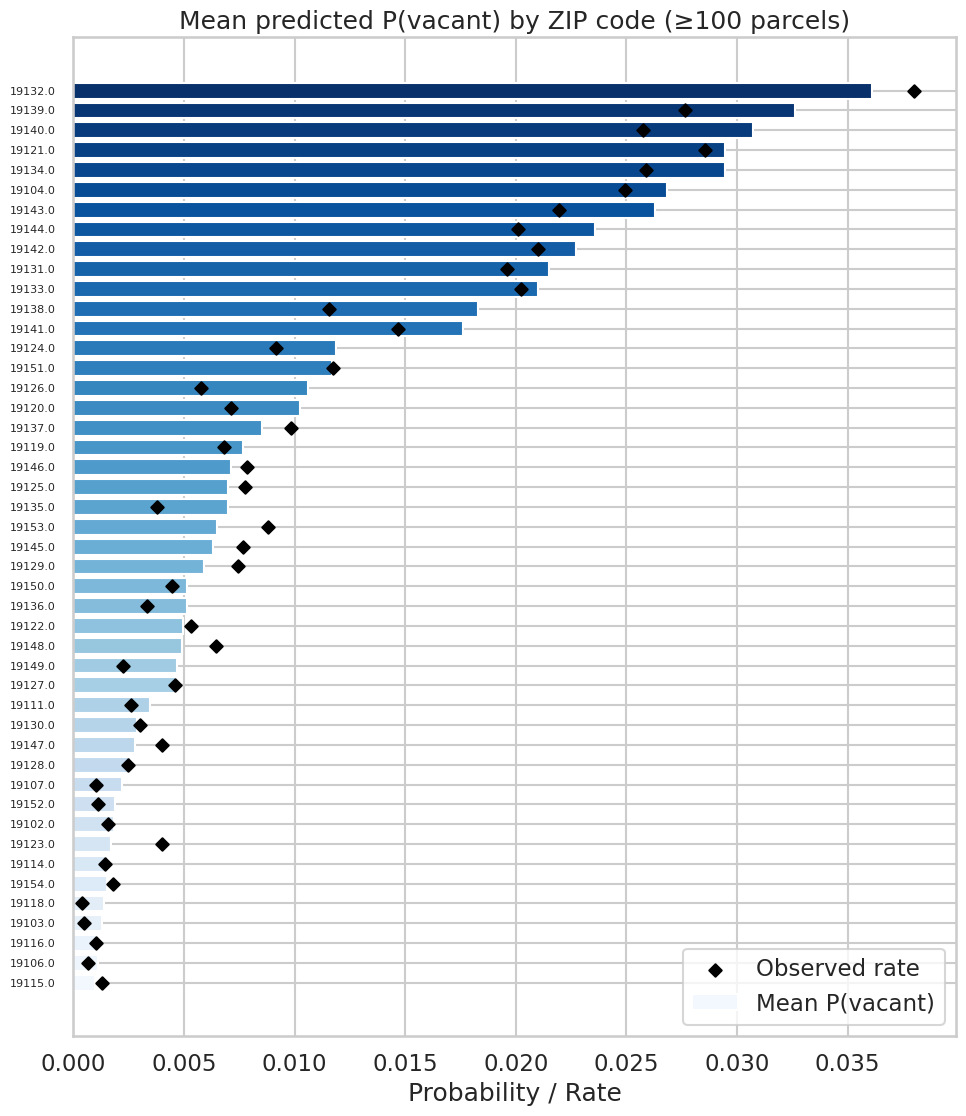

In [11]:
sub = zip_summary[zip_summary['n_parcels'] >= 100].sort_values('mean_pred_prob')
fig, ax = plt.subplots(figsize=(10, max(7, 0.25 * len(sub))))
y = np.arange(len(sub))
colors = plt.cm.Blues(sub['mean_pred_prob'].rank(pct=True))
ax.barh(y, sub['mean_pred_prob'], color=colors, label='Mean P(vacant)')
ax.scatter(sub['obs_rate'], y, color='black', marker='D', s=40, zorder=5,
           label='Observed rate')
ax.set_yticks(y)
ax.set_yticklabels(sub['zip_code'].astype(str), fontsize=8)
ax.set_xlabel('Probability / Rate')
ax.set_title('Mean predicted P(vacant) by ZIP code (≥100 parcels)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'zip_mean_prob_bar.png', dpi=200, bbox_inches='tight')
plt.show()


### 3c. Choropleth map (optional)

Uses `pygris` (Census TIGER) to fetch ZIP boundaries for Philly. Skips
gracefully if `pygris` isn't installed or the API call fails.


In [12]:
zcta_gdf = None
try:
    from pygris import zctas
    print('Fetching ZCTA boundaries via pygris (Census TIGER)…')
    z = zctas(year=2020, cb=True, cache=True)
    z = z.rename(columns={c: c.upper() for c in z.columns if c != z.geometry.name})
    zcta_col = next((c for c in ['ZCTA5CE20', 'ZCTA5CE10', 'GEOID20', 'GEOID']
                     if c in z.columns), None)
    if zcta_col is None:
        raise RuntimeError(f"No ZCTA column found. Columns: {list(z.columns)}")
    z = z[z[zcta_col].astype(str).str.startswith('191')]

    # zip_code in zip_summary is float (e.g. 19132.0). Cast to clean 5-digit string.
    zip_summary_clean = zip_summary.copy()
    zip_summary_clean['zip_code'] = (
        pd.to_numeric(zip_summary_clean['zip_code'], errors='coerce')
        .dropna().astype(int).astype(str).str.zfill(5)
    )
    zip_summary_clean = zip_summary_clean.dropna(subset=['zip_code'])

    z = z.merge(zip_summary_clean, left_on=zcta_col, right_on='zip_code', how='inner')
    zcta_gdf = z
    print(f"  {len(zcta_gdf)} ZIP polygons matched")
    if len(zcta_gdf) == 0:
        print(f"  [debug] pygris {zcta_col} sample: {z[zcta_col].astype(str).head(3).tolist()}")
        print(f"  [debug] zip_summary  sample: {zip_summary_clean['zip_code'].head(3).tolist()}")
except Exception as e:
    print(f'pygris ZCTA fetch failed — choropleth will be skipped: {e}')

Fetching ZCTA boundaries via pygris (Census TIGER)…
  47 ZIP polygons matched


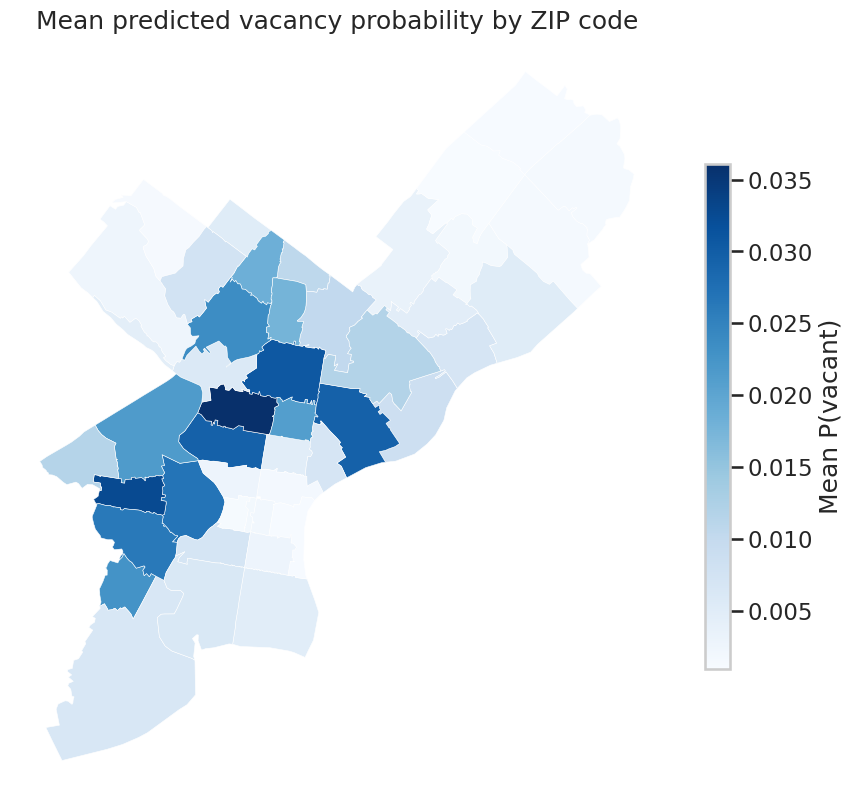

In [13]:
if zcta_gdf is not None and len(zcta_gdf) > 0:
    fig, ax = plt.subplots(figsize=(9, 9))
    zcta_gdf.plot(column='mean_pred_prob', cmap='Blues', legend=True,
                  edgecolor='white', linewidth=0.4, ax=ax,
                  legend_kwds={'label': 'Mean P(vacant)', 'shrink': 0.6})
    ax.set_axis_off()
    ax.set_title('Mean predicted vacancy probability by ZIP code')
    plt.tight_layout()
    plt.savefig(GRAPH_PATH / 'spatial_zip_choropleth.png', dpi=200, bbox_inches='tight')
    plt.show()


### 3d. Interactive Folium map (optional)

In [14]:
if zcta_gdf is not None and HAS_FOLIUM:
    map_data = zcta_gdf.to_crs(epsg=4326).copy()
    # Find the ZCTA column name (varies by tigris vintage)
    zcta_col = next((c for c in ['ZCTA5CE20', 'ZCTA5CE10', 'GEOID20', 'GEOID']
                     if c in map_data.columns), None)
    if zcta_col is None:
        print('Could not identify ZCTA column — folium map skipped.')
    else:
        # Standardize for folium: it needs a key column accessible via
        # feature.properties.<key>
        map_data['zcta_id'] = map_data[zcta_col].astype(str)

        m = folium.Map(location=[39.9526, -75.1652], zoom_start=11,
                       tiles='CartoDB positron')

        folium.Choropleth(
            geo_data=map_data.__geo_interface__,
            data=map_data[['zcta_id', 'mean_pred_prob']],
            columns=['zcta_id', 'mean_pred_prob'],
            key_on='feature.properties.zcta_id',
            fill_color='Blues', fill_opacity=0.7, line_opacity=0.3,
            legend_name='Mean P(vacant)',
        ).add_to(m)

        # Add hover tooltips with the actual numbers
        folium.GeoJson(
            map_data,
            style_function=lambda x: {'fillOpacity': 0, 'color': 'transparent'},
            tooltip=folium.GeoJsonTooltip(
                fields=['zcta_id', 'n_parcels', 'n_obs_vacant',
                        'obs_rate', 'mean_pred_prob'],
                aliases=['ZIP:', 'Parcels:', 'Observed vacant:',
                         'Observed rate:', 'Mean P(vacant):'],
                localize=True,
            ),
        ).add_to(m)

        out_html = OUT_PATH / 'vacancy_risk_map.html'
        m.save(str(out_html))
        print(f"Interactive map saved to {out_html}")
        m


Interactive map saved to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vacancy_risk_map.html


## 4. Capacity-based threshold table

Translates "we can inspect N properties" → recommended probability cutoff,
along with expected precision and recall.


In [15]:
# Use raw ensemble probability so the threshold table covers the full 0–1 range.
# (Calibrated probs are squashed below ~0.6 so a "threshold = 0.5" lookup is
# meaningless on calibrated.)
labeled = analysis.dropna(subset=['ovs', prob_raw_col])
score = labeled[prob_raw_col].values
y     = labeled['ovs'].astype(int).values
print(f"Capacity table built on {len(labeled):,} labeled parcels  "
      f"({int((y == 1).sum()):,} positives)")

thresholds_seq = np.arange(0.01, 0.99, 0.01)
rows = []
for t in thresholds_seq:
    flagged = score >= t
    n_flag  = int(flagged.sum())
    if n_flag == 0:
        continue
    n_tp = int(((flagged) & (y == 1)).sum())
    rows.append({
        'threshold': round(float(t), 3),
        'n_flagged': n_flag,
        'precision': n_tp / n_flag,
        'recall':    n_tp / max(int((y == 1).sum()), 1),
    })
capacity_df = pd.DataFrame(rows)
capacity_df.head()


Capacity table built on 520,196 labeled parcels  (5,934 positives)


,threshold,n_flagged,precision,recall
0,0.01,503510,0.011783,0.999831
1,0.02,454074,0.013062,0.999494
2,0.03,399867,0.014812,0.998146
3,0.04,354925,0.016660,0.996461
4,0.05,316321,0.018665,0.994944


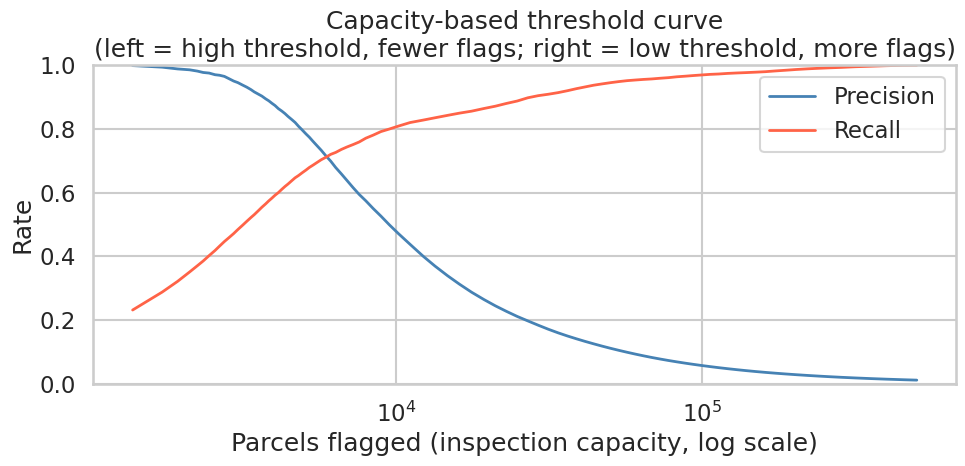

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(capacity_df['n_flagged'], capacity_df['precision'], label='Precision',
        color='steelblue', lw=2)
ax.plot(capacity_df['n_flagged'], capacity_df['recall'],    label='Recall',
        color='tomato', lw=2)
ax.set_xscale('log')
ax.set_xlabel('Parcels flagged (inspection capacity, log scale)')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
ax.set_title('Capacity-based threshold curve\n'
             '(left = high threshold, fewer flags; right = low threshold, more flags)')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'capacity_threshold_curve.png', dpi=200, bbox_inches='tight')
plt.show()


In [17]:
capacity_targets = [100, 250, 500, 1000, 2000, 5000, 10000]
rows = []
for cap in capacity_targets:
    candidate = capacity_df[capacity_df['n_flagged'] >= cap]
    if len(candidate) == 0:
        rows.append({'target_capacity': cap, 'n_flagged': np.nan,
                     'threshold': np.nan, 'precision': np.nan, 'recall': np.nan})
        continue
    row = candidate.loc[candidate['n_flagged'].idxmin()].to_dict()
    row['target_capacity'] = cap
    rows.append(row)
capacity_lookup = pd.DataFrame(rows)[
    ['target_capacity', 'n_flagged', 'threshold', 'precision', 'recall']
]
capacity_lookup['precision'] = capacity_lookup['precision'].map(
    lambda v: f"{v:.1%}" if pd.notnull(v) else '—')
capacity_lookup['recall']    = capacity_lookup['recall'].map(
    lambda v: f"{v:.1%}" if pd.notnull(v) else '—')
capacity_lookup


,target_capacity,n_flagged,threshold,precision,recall
0,100,1377.0,0.98,99.9%,23.2%
1,250,1377.0,0.98,99.9%,23.2%
2,500,1377.0,0.98,99.9%,23.2%
3,1000,1377.0,0.98,99.9%,23.2%
4,2000,2114.0,0.95,98.5%,35.1%
5,5000,5077.0,0.67,78.4%,67.1%
6,10000,10177.0,0.51,47.2%,80.9%


## 5. Export summaries

In [18]:
zip_summary.to_csv(OUT_PATH / 'output_zip_summary.csv', index=False)
type_summary.to_csv(OUT_PATH / 'output_category_summary.csv', index=False)
capacity_df.to_csv(OUT_PATH / 'capacity_threshold_curve.csv', index=False)
print('Exported output_zip_summary.csv, output_category_summary.csv, capacity_threshold_curve.csv')

print(f"\n--- 05 Output Analysis Summary ---")
print(f"Parcels analyzed:        {len(analysis):,}")
print(f"ZIP codes covered:       {analysis['zip_code'].nunique(dropna=True)}")
print(f"Property categories:     {analysis['category_code_description'].nunique(dropna=True)}")
print(f"Mean ensemble P(vacant): {analysis[prob_col].mean():.4f}")


Exported output_zip_summary.csv, output_category_summary.csv, capacity_threshold_curve.csv

--- 05 Output Analysis Summary ---
Parcels analyzed:        520,196
ZIP codes covered:       47
Property categories:     4
Mean ensemble P(vacant): 0.0128


## 6. GeoJSON export (optional — heavy)

Joins predictions onto PWD parcel polygons (`PWD_PARCELS.geojson`, ~420 MB)
and writes three GeoJSON files: full, flagged-only (top 1%), simplified.

> **Default: SKIP this section.** It needs ~30–60 GB of RAM and takes 15+
> minutes. Set `RUN_GEOJSON_EXPORT = True` only when you actually need the
> spatial export for the dashboard team.


In [19]:
RUN_GEOJSON_EXPORT = True  # set True only when you want the heavy spatial export

if RUN_GEOJSON_EXPORT and HAS_GPD:
    pwd_path = RAW_PATH / 'PWD_PARCELS.geojson'
    if not pwd_path.exists():
        print(f"PWD_PARCELS.geojson not found at {pwd_path} — skipping export")
    else:
        print(f"Loading PWD_PARCELS.geojson ({pwd_path.stat().st_size / 1e6:.0f} MB)…")
        parcels_sf = gpd.read_file(pwd_path)
        parcels_sf.columns = [c.lower() for c in parcels_sf.columns]
        if 'brt_id' in parcels_sf.columns:
            parcels_sf = parcels_sf.rename(columns={'brt_id': 'parcel_number'})
        parcels_sf['parcel_number'] = parcels_sf['parcel_number'].astype(str)
        print(f"Loaded {len(parcels_sf):,} polygons")

        # Join
        export_cols = ['parcel_number', 'ovs', 'data_split',
                       prob_col, prob_raw_col, 'risk_score',
                       'qtile_tier', 'ensemble_flag',
                       'rf_prob', 'logit_prob', 'xgb_prob', 'lgb_prob',
                       'rf_flag', 'logit_flag', 'xgb_flag', 'lgb_flag',
                       'zip_code', 'census_tract', 'geographic_ward', 'address']
        export_cols = [c for c in export_cols if c in analysis.columns]

        sf_out = parcels_sf[['parcel_number', 'geometry']].merge(
            analysis[export_cols], on='parcel_number', how='inner',
        ).to_crs(epsg=4326)

        full_path = OUT_PATH / 'vacancy_predictions.geojson'
        sf_out.to_file(full_path, driver='GeoJSON')
        print(f"Exported {full_path} ({len(sf_out):,} parcels, "
              f"{full_path.stat().st_size / 1e6:.0f} MB)")

        # Flagged-only
        if 'ensemble_flag' in sf_out.columns:
            flagged = sf_out[sf_out['ensemble_flag'] == 1]
            flagged_path = OUT_PATH / 'vacancy_predictions_flagged.geojson'
            flagged.to_file(flagged_path, driver='GeoJSON')
            print(f"Exported {flagged_path} ({len(flagged):,} parcels, "
                  f"{flagged_path.stat().st_size / 1e6:.0f} MB)")
else:
    print('GeoJSON export skipped (RUN_GEOJSON_EXPORT=False or geopandas missing).')


Loading PWD_PARCELS.geojson (442 MB)…
Loaded 547,220 polygons
Exported /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vacancy_predictions.geojson (436,290 parcels, 405 MB)
Exported /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vacancy_predictions_flagged.geojson (4,518 parcels, 4 MB)


---
**Done.** All summary CSVs written to `data_py/`. The optional choropleth and
interactive Folium map are in `graphs/python/` and `data_py/`. To produce the
heavy parcel-polygon GeoJSON, set `RUN_GEOJSON_EXPORT = True` in §6.


In [20]:
gdf = gpd.read_file('/content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/vacancy_predictions_flagged.geojson')

# List all column names
print(gdf.columns)

# View the first few rows of data
print(gdf.head())

Index(['parcel_number', 'ovs', 'data_split', 'ensemble_prob',
       'ensemble_prob_raw', 'risk_score', 'qtile_tier', 'ensemble_flag',
       'rf_prob', 'logit_prob', 'xgb_prob', 'lgb_prob', 'rf_flag',
       'logit_flag', 'xgb_flag', 'lgb_flag', 'zip_code', 'census_tract',
       'geographic_ward', 'address', 'geometry'],
      dtype='object')
  parcel_number  ovs data_split  ensemble_prob  ensemble_prob_raw  risk_score  \
0     121126100    1      train       0.344340           0.713196          34   
1     121221600    0      train       0.431818           0.797984          43   
2     331411400    1      train       1.000000           0.991059         100   
3     332090600    1      train       0.946429           0.973451          95   
4     881215515    0      train       0.220859           0.660771          22   

              qtile_tier  ensemble_flag   rf_prob  logit_prob  ...  lgb_prob  \
0  Top 1% (highest risk)              1  0.583333    0.020237  ...  0.775713   
1  Top

In [21]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/05_output_analysis.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/05_output_analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1017016 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/05_output_analysis.html
